In [1]:
"""04_acs_5year_ingest.py"""

'04_acs_5year_ingest.py'

# ACS 5-year ingest and preview for Puerto Rico counties, tracts, and block groups

This notebook now runs before the urban-block notebook because it materializes
the 2020 and 2024 ACS slices that downstream urban summaries depend on. The
workflow intentionally keeps one shared, block-group-safe variable set across
counties, tracts, and block groups so the fetch stays compact and the derived
metrics remain consistent across geographies.

References:
- https://censusdis.readthedocs.io/en/latest/nb/ACS%20Demo.html
- https://censusdis.readthedocs.io/en/latest/nb/Population%20Change%202020-2021.html#Part-1:-Using-ACS5-Data
- https://api.census.gov/data/2024/acs/acs5/variables.html

In [2]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import Image


def _bootstrap_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    markers = ("project_rules.md", ".git")
    for candidate in (current, *current.parents):
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    return current


PROJECT_ROOT = _bootstrap_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.acs import ACS_GEOGRAPHY_ORDER
from utils.acs import append_geoid
from utils.acs import artifact_path_for_acs
from utils.acs import coerce_numeric_columns
from utils.acs import download_acs_dataset
from utils.acs import get_acs_geography_spec
from utils.acs import load_product_catalog
from utils.acs import load_summary_level_catalog
from utils.acs import persist_dataframe
from utils.acs import table_name_for_acs
from utils.census import create_spatial_connection
from utils.census import resolve_vector_db_path


def parse_acs_vintages(raw_value: str) -> tuple[int, ...]:
    """Parse a comma-separated vintage list like ``2020,2024``."""

    vintages = sorted({int(token.strip()) for token in raw_value.split(",") if token.strip()})
    if not vintages:
        raise ValueError("ACS_5YEAR_VINTAGES must contain at least one vintage year")
    return tuple(vintages)


ACS_VINTAGES = parse_acs_vintages(os.getenv("ACS_5YEAR_VINTAGES", "2020"))
PRIMARY_ACS_VINTAGE = int(os.getenv("ACS_PRIMARY_VINTAGE", str(max(ACS_VINTAGES))))
TARGET_GEOGRAPHIES = ACS_GEOGRAPHY_ORDER
TARGET_MUNICIPALITIES = ("San Juan", "Isabela")
PREVIEW_GEOGRAPHY = os.getenv("ACS_PREVIEW_GEOGRAPHY", "block_group")
PREVIEW_FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
PREVIEW_METRICS = (
    "median_household_income_usd",
    "poverty_rate",
    "pct_owner_occupied",
    "pct_english_only",
)
PREVIEW_METRIC_LABELS = {
    "median_household_income_usd": "Median household income",
    "poverty_rate": "Poverty rate",
    "pct_owner_occupied": "Owner-occupied share",
    "pct_english_only": "English-only share",
}
REFERENCE_SUMMARY_LEVELS = tuple(get_acs_geography_spec(geography).summary_level for geography in TARGET_GEOGRAPHIES)

if PRIMARY_ACS_VINTAGE not in ACS_VINTAGES:
    raise ValueError(
        f"ACS_PRIMARY_VINTAGE={PRIMARY_ACS_VINTAGE} is not in ACS_5YEAR_VINTAGES={ACS_VINTAGES}"
    )

SHARED_ACS_VARIABLES: dict[str, str] = {
    "B01003_001E": "total_population",
    "B19013_001E": "median_household_income_usd",
    "C17002_001E": "poverty_universe",
    "C17002_002E": "poverty_ratio_under_50",
    "C17002_003E": "poverty_ratio_50_99",
    "B25001_001E": "total_housing_units",
    "B25003_001E": "tenure_total",
    "B25003_002E": "tenure_owner_occupied",
    "B25003_003E": "tenure_renter_occupied",
    "B25077_001E": "median_home_value_usd",
    "B03002_001E": "race_total",
    "B03002_003E": "nh_white_alone",
    "B03002_004E": "nh_black_alone",
    "B03002_005E": "nh_aian_alone",
    "B03002_006E": "nh_asian_alone",
    "B03002_007E": "nh_nhpi_alone",
    "B03002_008E": "nh_other_alone",
    "B03002_009E": "nh_two_or_more",
    "B03002_012E": "hispanic_or_latino",
    "B15003_001E": "edu_total_25plus",
    "B15003_017E": "edu_high_school",
    "B15003_018E": "edu_ged",
    "B15003_019E": "edu_some_college_lt1",
    "B15003_020E": "edu_some_college_gt1",
    "B15003_021E": "edu_associate",
    "B15003_022E": "edu_bachelors",
    "B15003_023E": "edu_masters",
    "B15003_024E": "edu_professional",
    "B15003_025E": "edu_doctorate",
    "B16004_001E": "language_population_5plus",
    "B16004_003E": "english_only_5_17",
    "B16004_004E": "spanish_speaking_5_17",
    "B16004_006E": "spanish_english_well_5_17",
    "B16004_007E": "spanish_english_not_well_5_17",
    "B16004_008E": "spanish_english_not_at_all_5_17",
    "B16004_025E": "english_only_18_64",
    "B16004_026E": "spanish_speaking_18_64",
    "B16004_028E": "spanish_english_well_18_64",
    "B16004_029E": "spanish_english_not_well_18_64",
    "B16004_030E": "spanish_english_not_at_all_18_64",
    "B16004_047E": "english_only_65plus",
    "B16004_048E": "spanish_speaking_65plus",
    "B16004_050E": "spanish_english_well_65plus",
    "B16004_051E": "spanish_english_not_well_65plus",
    "B16004_052E": "spanish_english_not_at_all_65plus",
}

GEOGRAPHY_EXTRA_VARIABLES: dict[str, dict[str, str]] = {}

DI_GROUP_COLS = (
    "nh_white_alone",
    "nh_black_alone",
    "nh_aian_alone",
    "nh_asian_alone",
    "nh_nhpi_alone",
    "nh_other_alone",
    "nh_two_or_more",
    "hispanic_or_latino",
)
EDU_HIGH_SCHOOL_PLUS_COLS = (
    "edu_high_school",
    "edu_ged",
    "edu_some_college_lt1",
    "edu_some_college_gt1",
    "edu_associate",
    "edu_bachelors",
    "edu_masters",
    "edu_professional",
    "edu_doctorate",
)
EDU_BACHELOR_PLUS_COLS = ("edu_bachelors", "edu_masters", "edu_professional", "edu_doctorate")
SPANISH_SPEAKING_COLS = ("spanish_speaking_5_17", "spanish_speaking_18_64", "spanish_speaking_65plus")
ENGLISH_ONLY_COLS = ("english_only_5_17", "english_only_18_64", "english_only_65plus")
LIMITED_ENGLISH_COLS = (
    "spanish_english_well_5_17",
    "spanish_english_not_well_5_17",
    "spanish_english_not_at_all_5_17",
    "spanish_english_well_18_64",
    "spanish_english_not_well_18_64",
    "spanish_english_not_at_all_18_64",
    "spanish_english_well_65plus",
    "spanish_english_not_well_65plus",
    "spanish_english_not_at_all_65plus",
)
GEOGRAPHY_COMPONENT_RENAMES = {
    "state": "STATE",
    "county": "COUNTY",
    "tract": "TRACT",
    "block group": "BLOCK_GROUP",
}


def selected_variables_for_geography(geography: str) -> dict[str, str]:
    """Return the ACS variable map for a target geography."""

    spec = get_acs_geography_spec(geography)
    return SHARED_ACS_VARIABLES | GEOGRAPHY_EXTRA_VARIABLES.get(spec.geography, {})


def resolve_restriction_column(product_catalog: pd.DataFrame) -> str:
    """Return the catalog column that stores 5-year geography restrictions."""

    for column in product_catalog.columns:
        normalized = column.lower().replace("-", " ")
        if "5 year" in normalized and "geography restrictions" in normalized:
            return column
    raise KeyError("Could not find the 5-year geography restriction column in the ACS product catalog")


def load_reference_metadata(year: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load the ACS catalog rows relevant to the selected project tables."""

    product_catalog = load_product_catalog(year=year)
    restriction_column = resolve_restriction_column(product_catalog)
    product_frames: list[pd.DataFrame] = []
    for geography in TARGET_GEOGRAPHIES:
        selected_table_ids = sorted(
            {variable.split("_", 1)[0] for variable in selected_variables_for_geography(geography)}
        )
        product_subset = product_catalog[product_catalog["Table ID"].isin(selected_table_ids)].copy()
        product_subset.insert(0, "geography", geography)
        product_frames.append(
            product_subset[
                [
                    "geography",
                    "Table ID",
                    "Table Title",
                    restriction_column,
                ]
            ]
            .rename(columns={restriction_column: "5-Year Geography Restrictions (with Summary Levels in Parentheses)"})
            .sort_values(["geography", "Table ID"])
        )

    summary_levels = load_summary_level_catalog()
    summary_subset = summary_levels[summary_levels["Summary Level Code"].isin(REFERENCE_SUMMARY_LEVELS)].copy()
    summary_subset = summary_subset[
        [
            "Summary Level Code",
            "Summary Level Description",
            "Detailed Tables",
        ]
    ].sort_values("Summary Level Code")
    return pd.concat(product_frames, ignore_index=True), summary_subset


def assert_selected_tables_support_target_geographies(product_metadata: pd.DataFrame) -> None:
    """Fail early if a selected table excludes the geography it was assigned to."""

    restriction_column = "5-Year Geography Restrictions (with Summary Levels in Parentheses)"
    blocked: list[str] = []
    for geography, group in product_metadata.groupby("geography"):
        summary_level = get_acs_geography_spec(geography).summary_level
        for _, row in group.iterrows():
            restriction_text = row[restriction_column] if pd.notna(row[restriction_column]) else ""
            if summary_level in str(restriction_text):
                blocked.append(f"{geography} -> {row['Table ID']}: {restriction_text}")

    if blocked:
        details = "\n".join(blocked)
        raise RuntimeError(f"Selected ACS tables exclude a target geography level:\n{details}")


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """Return a float ratio with divide-by-zero handled as missing."""

    return numerator / denominator.replace(0, pd.NA)


def _to_bytes(value: object) -> bytes:
    """Normalize DuckDB WKB outputs into plain bytes."""

    if isinstance(value, memoryview):
        return value.tobytes()
    if isinstance(value, bytearray):
        return bytes(value)
    if isinstance(value, bytes):
        return value
    return bytes(value)


def prepare_acs_frame(raw_frame: pd.DataFrame, geography: str) -> pd.DataFrame:
    """Rename columns, build GEOIDs, and derive ready-to-use ACS metrics."""

    spec = get_acs_geography_spec(geography)
    selected_variables = selected_variables_for_geography(geography)
    frame = coerce_numeric_columns(raw_frame, list(selected_variables.keys()))
    frame = append_geoid(frame, geography)
    frame = frame.rename(columns=selected_variables | GEOGRAPHY_COMPONENT_RENAMES)
    frame.insert(0, "geography_level", spec.geography)

    frame["below_poverty_count"] = frame[["poverty_ratio_under_50", "poverty_ratio_50_99"]].sum(
        axis=1,
        min_count=1,
    )
    frame["pct_owner_occupied"] = safe_ratio(frame["tenure_owner_occupied"], frame["tenure_total"])
    frame["pct_high_school_plus"] = safe_ratio(frame[list(EDU_HIGH_SCHOOL_PLUS_COLS)].sum(axis=1), frame["edu_total_25plus"])
    frame["pct_bachelor_plus"] = safe_ratio(frame[list(EDU_BACHELOR_PLUS_COLS)].sum(axis=1), frame["edu_total_25plus"])
    frame["poverty_rate"] = safe_ratio(frame["below_poverty_count"], frame["poverty_universe"])

    total = frame["race_total"].replace(0, pd.NA)
    sum_sq = sum((frame[column] / total) ** 2 for column in DI_GROUP_COLS)
    frame["diversity_index"] = 1 - sum_sq
    frame["pct_hispanic_or_latino"] = safe_ratio(frame["hispanic_or_latino"], frame["race_total"])
    frame["pct_nonhispanic_white"] = safe_ratio(frame["nh_white_alone"], frame["race_total"])
    frame["pct_nonhispanic_black"] = safe_ratio(frame["nh_black_alone"], frame["race_total"])

    frame["spanish_speaking_count"] = frame[list(SPANISH_SPEAKING_COLS)].sum(axis=1, min_count=1)
    frame["english_only_count"] = frame[list(ENGLISH_ONLY_COLS)].sum(axis=1, min_count=1)
    frame["limited_english_count"] = frame[list(LIMITED_ENGLISH_COLS)].sum(axis=1, min_count=1)
    frame["pct_english_only"] = safe_ratio(frame["english_only_count"], frame["language_population_5plus"])
    frame["pct_spanish_speaking"] = safe_ratio(frame["spanish_speaking_count"], frame["language_population_5plus"])
    frame["pct_limited_english"] = safe_ratio(frame["limited_english_count"], frame["language_population_5plus"])

    component_columns = [GEOGRAPHY_COMPONENT_RENAMES[column] for column in spec.geoid_components]
    keep = [
        "geography_level",
        *component_columns,
        spec.geoid_column,
        "NAME",
        *selected_variables.values(),
        "below_poverty_count",
        "pct_owner_occupied",
        "pct_high_school_plus",
        "pct_bachelor_plus",
        "poverty_rate",
        "diversity_index",
        "pct_hispanic_or_latino",
        "pct_nonhispanic_white",
        "pct_nonhispanic_black",
        "spanish_speaking_count",
        "english_only_count",
        "limited_english_count",
        "pct_english_only",
        "pct_spanish_speaking",
        "pct_limited_english",
    ]
    ordered_keep: list[str] = []
    for column in keep:
        if column in frame.columns and column not in ordered_keep:
            ordered_keep.append(column)
    return frame[ordered_keep].copy()


def fetch_project_acs_tables(year: int) -> dict[str, pd.DataFrame]:
    """Fetch and prepare the project ACS slices for all target geographies."""

    frames: dict[str, pd.DataFrame] = {}
    for geography in TARGET_GEOGRAPHIES:
        spec = get_acs_geography_spec(geography)
        selected_variables = selected_variables_for_geography(geography)
        print(f"[fetch] {spec.output_name} ({year}) …")
        raw_frame = download_acs_dataset(year, list(selected_variables.keys()), geography)
        frames[geography] = prepare_acs_frame(raw_frame, geography)
        print(f"        {len(frames[geography]):,} rows")
    return frames


def persist_acs_outputs(
    con,
    frames: dict[str, pd.DataFrame],
    *,
    year: int,
) -> pd.DataFrame:
    """Persist ACS slices to DuckDB and parquet artifacts."""

    records: list[dict[str, object]] = []
    for geography, frame in frames.items():
        table_name = table_name_for_acs(year, geography)
        artifact_path = artifact_path_for_acs(year, geography)
        artifact_path.parent.mkdir(parents=True, exist_ok=True)

        persist_dataframe(con, table_name, frame)
        frame.to_parquet(artifact_path, index=False)
        records.append(
            {
                "year": year,
                "geography": geography,
                "table_name": table_name,
                "artifact_path": str(artifact_path),
                "row_count": len(frame),
            }
        )
    return pd.DataFrame(records)


def summarize_geometry_coverage(con, *, year: int) -> pd.DataFrame:
    """Return the join coverage between each ACS table and its geometry table."""

    summaries: list[pd.DataFrame] = []
    for geography in TARGET_GEOGRAPHIES:
        spec = get_acs_geography_spec(geography)
        table_name = table_name_for_acs(year, geography)
        summaries.append(
            con.execute(
                f"""
                SELECT {year} AS vintage,
                       '{geography}' AS geography,
                       COUNT(*) AS acs_rows,
                       SUM(CASE WHEN geom.GEOID IS NOT NULL THEN 1 ELSE 0 END) AS matched_geometry_rows,
                       SUM(CASE WHEN geom.GEOID IS NULL THEN 1 ELSE 0 END) AS missing_geometry_rows
                FROM {table_name} AS acs
                LEFT JOIN {spec.geometry_table} AS geom
                  ON geom.GEOID = acs.{spec.geoid_column};
                """
            ).fetchdf()
        )
    return pd.concat(summaries, ignore_index=True)


def load_case_study_geodataframe(con, *, year: int, geography: str = PREVIEW_GEOGRAPHY) -> gpd.GeoDataFrame:
    """Return a case-study GeoDataFrame for preview plots."""

    spec = get_acs_geography_spec(geography)
    table_name = table_name_for_acs(year, geography)
    municipality_sql = ", ".join(f"'{municipio}'" for municipio in TARGET_MUNICIPALITIES)

    if spec.geography == "county":
        query = f"""
            SELECT acs.*,
                   geom.NAME AS municipio,
                   ST_AsWKB(geom.geometry) AS geometry
            FROM {table_name} AS acs
            JOIN {spec.geometry_table} AS geom
              ON geom.GEOID = acs.{spec.geoid_column}
            WHERE geom.NAME IN ({municipality_sql})
            ORDER BY municipio, acs.{spec.geoid_column};
        """
    else:
        query = f"""
            SELECT acs.*,
                   muni.NAME AS municipio,
                   ST_AsWKB(geom.geometry) AS geometry
            FROM {table_name} AS acs
            JOIN {spec.geometry_table} AS geom
              ON geom.GEOID = acs.{spec.geoid_column}
            JOIN pr_census_counties AS muni
              ON ST_Within(ST_Centroid(geom.geometry), muni.geometry)
            WHERE muni.NAME IN ({municipality_sql})
            ORDER BY municipio, acs.{spec.geoid_column};
        """

    frame = con.execute(query).fetchdf()
    if frame.empty:
        return gpd.GeoDataFrame(frame, geometry=gpd.GeoSeries([], crs="EPSG:4326"), crs="EPSG:4326")

    geometry = gpd.GeoSeries.from_wkb(frame.pop("geometry").map(_to_bytes), crs="EPSG:4326")
    return gpd.GeoDataFrame(frame, geometry=geometry, crs="EPSG:4326")


def summarize_case_study_metrics(con, *, year: int, geography: str = PREVIEW_GEOGRAPHY) -> pd.DataFrame:
    """Summarize preview metrics for the case-study municipalities."""

    gdf = load_case_study_geodataframe(con, year=year, geography=geography)
    if gdf.empty:
        return pd.DataFrame()

    records: list[dict[str, object]] = []
    for municipio, group in gdf.groupby("municipio"):
        record: dict[str, object] = {"municipio": municipio, "rows": len(group)}
        for metric in PREVIEW_METRICS:
            record[f"{metric}_median"] = group[metric].median(skipna=True)
            record[f"{metric}_nulls"] = int(group[metric].isna().sum())
        records.append(record)
    return pd.DataFrame(records).sort_values("municipio").reset_index(drop=True)


def preview_figure_path(year: int, geography: str, municipio: str) -> Path:
    """Return the output path for a case-study choropleth preview."""

    slug = municipio.lower().replace(" ", "_")
    return PREVIEW_FIGURE_DIR / f"acs_{year}_{geography}_{slug}_preview.png"


def plot_case_study_choropleths(con, *, year: int, geography: str = PREVIEW_GEOGRAPHY) -> list[Path]:
    """Write small static choropleth previews for the case-study municipalities."""

    gdf = load_case_study_geodataframe(con, year=year, geography=geography)
    if gdf.empty:
        return []

    PREVIEW_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    saved_paths: list[Path] = []
    for municipio in TARGET_MUNICIPALITIES:
        municipality_gdf = gdf[gdf["municipio"] == municipio].copy()
        if municipality_gdf.empty:
            continue

        fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)
        for ax, metric in zip(axes.flat, PREVIEW_METRICS):
            label = PREVIEW_METRIC_LABELS[metric]
            series = municipality_gdf[metric].dropna()
            if series.empty:
                ax.set_title(f"{label}\n(no valid data)")
                ax.axis("off")
                continue

            plot_kwargs = {
                "column": metric,
                "cmap": "YlGnBu",
                "linewidth": 0.15,
                "edgecolor": "white",
                "legend": True,
                "ax": ax,
                "missing_kwds": {"color": "#d9d9d9", "label": "No data"},
            }
            if len(series) >= 10:
                vmin = float(series.quantile(0.05))
                vmax = float(series.quantile(0.95))
                if vmin < vmax:
                    plot_kwargs["vmin"] = vmin
                    plot_kwargs["vmax"] = vmax

            municipality_gdf.plot(**plot_kwargs)
            ax.set_title(label)
            ax.axis("off")

        fig.suptitle(f"ACS {year} {geography.replace('_', ' ')} preview — {municipio}")
        output_path = preview_figure_path(year, geography, municipio)
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
        plt.close(fig)
        saved_paths.append(output_path)
    return saved_paths

## Step 1 — Validate the selected ACS tables against the supplied catalogs

The repository already includes both the 2020 and 2024 ACS product catalogs.
We validate each requested geography against the local catalog before issuing
any API requests. The poverty metric is sourced from `C17002` rather than
`B17001` because the latter excludes block groups.

In [3]:
catalog_summaries: list[pd.DataFrame] = []
summary_metadata = pd.DataFrame()
for vintage in ACS_VINTAGES:
    product_metadata, summary_metadata = load_reference_metadata(vintage)
    assert_selected_tables_support_target_geographies(product_metadata)
    print(f"Selected ACS tables for {vintage}:")
    print(product_metadata.to_string(index=False))
    print()
    catalog_summaries.append(product_metadata.assign(vintage=vintage))

print("Summary levels used by this notebook:")
print(summary_metadata.to_string(index=False))

Selected ACS tables for 2020:
  geography Table ID                                                                                    Table Title 5-Year Geography Restrictions (with Summary Levels in Parentheses)
     county   B01003                                                                               TOTAL POPULATION                                                                NaN
     county   B03002                                                              HISPANIC OR LATINO ORIGIN BY RACE                                     Excludes Place/Remainder (070)
     county   B15003                                    EDUCATIONAL ATTAINMENT FOR THE POPULATION 25 YEARS AND OVER                                     Excludes Place/Remainder (070)
     county   B16004 AGE BY LANGUAGE SPOKEN AT HOME BY ABILITY TO SPEAK ENGLISH FOR THE POPULATION 5 YEARS AND OVER                                     Excludes Place/Remainder (070)
     county   B19013             MEDIAN HOUSEHOLD INCOM

## Step 2 — Fetch Puerto Rico ACS 5-year rows for each configured vintage

The default configuration fetches both 2020 and 2024 so the urban-block
notebook can anchor to 2020 denominators while downstream socioeconomic
analysis still has the latest 2024 context.

In [4]:
acs_tables_by_year = {vintage: fetch_project_acs_tables(vintage) for vintage in ACS_VINTAGES}

[fetch] counties (2020) …
        78 rows
[fetch] tracts (2020) …
        981 rows
[fetch] block_groups (2020) …
        2,555 rows


## Step 3 — Persist the ACS slices to DuckDB and parquet artifacts

Each geography gets one DuckDB table and one parquet artifact per vintage.

In [5]:
db_path = resolve_vector_db_path()
con = create_spatial_connection(db_path)
persistence_frames = [persist_acs_outputs(con, frames, year=vintage) for vintage, frames in acs_tables_by_year.items()]
persistence_summary = pd.concat(persistence_frames, ignore_index=True)
print(persistence_summary.to_string(index=False))

 year   geography               table_name                                                                                   artifact_path  row_count
 2020      county     pr_acs_2020_counties     /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/acs_2020_5yr_counties.parquet         78
 2020       tract       pr_acs_2020_tracts       /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/acs_2020_5yr_tracts.parquet        981
 2020 block_group pr_acs_2020_block_groups /home/asvnpr/Documents/repos/PLAN6068_PV_Project/data/tabular/acs_2020_5yr_block_groups.parquet       2555


## Step 4 — Confirm that each ACS slice joins cleanly to the existing geometry tables

These counts are a quick ingest-level verification that the Census GEOIDs we
just saved line up with the geometry layers already stored in DuckDB.

In [6]:
coverage_summary = pd.concat(
    [summarize_geometry_coverage(con, year=vintage) for vintage in ACS_VINTAGES],
    ignore_index=True,
)
print(coverage_summary.to_string(index=False))

 vintage   geography  acs_rows  matched_geometry_rows  missing_geometry_rows
    2020      county        78                   78.0                    0.0
    2020       tract       981                  939.0                   42.0
    2020 block_group      2555                 2513.0                   42.0


## Step 5 — Generate case-study previews after sentinel cleanup

The preview maps use the primary vintage and intentionally focus on the two
municipalities that drive the downstream raster case studies.

In [7]:
case_study_summary = summarize_case_study_metrics(con, year=PRIMARY_ACS_VINTAGE)
if case_study_summary.empty:
    print("No case-study geometry rows were available for ACS previews.")
else:
    print(case_study_summary.to_string(index=False))

preview_paths = plot_case_study_choropleths(con, year=PRIMARY_ACS_VINTAGE)
if preview_paths:
    print("\nSaved preview figures:")
    for path in preview_paths:
        print(f"- {path}")
else:
    print("\nNo preview figures were written.")

print(f"\nSaved DuckDB spatial database to: {db_path}")
print("Created/updated tables:")
for vintage in ACS_VINTAGES:
    for geography in TARGET_GEOGRAPHIES:
        print(f"- {table_name_for_acs(vintage, geography)}")
con.close()

municipio  rows  median_household_income_usd_median  median_household_income_usd_nulls  poverty_rate_median  poverty_rate_nulls  pct_owner_occupied_median  pct_owner_occupied_nulls  pct_english_only_median  pct_english_only_nulls
  Isabela    29                             17164.0                                  3             0.518960                   0                   0.603550                         0                 0.050830                       0
 San Juan   361                             24667.0                                 52             0.380658                  10                   0.566057                        10                 0.065569                       9

Saved preview figures:
- /home/asvnpr/Documents/repos/PLAN6068_PV_Project/outputs/figures/acs_2020_block_group_san_juan_preview.png
- /home/asvnpr/Documents/repos/PLAN6068_PV_Project/outputs/figures/acs_2020_block_group_isabela_preview.png

Saved DuckDB spatial database to: /home/asvnpr/Documents/repos/PLAN6

/home/asvnpr/Documents/repos/PLAN6068_PV_Project/outputs/figures/acs_2020_block_group_san_juan_preview.png


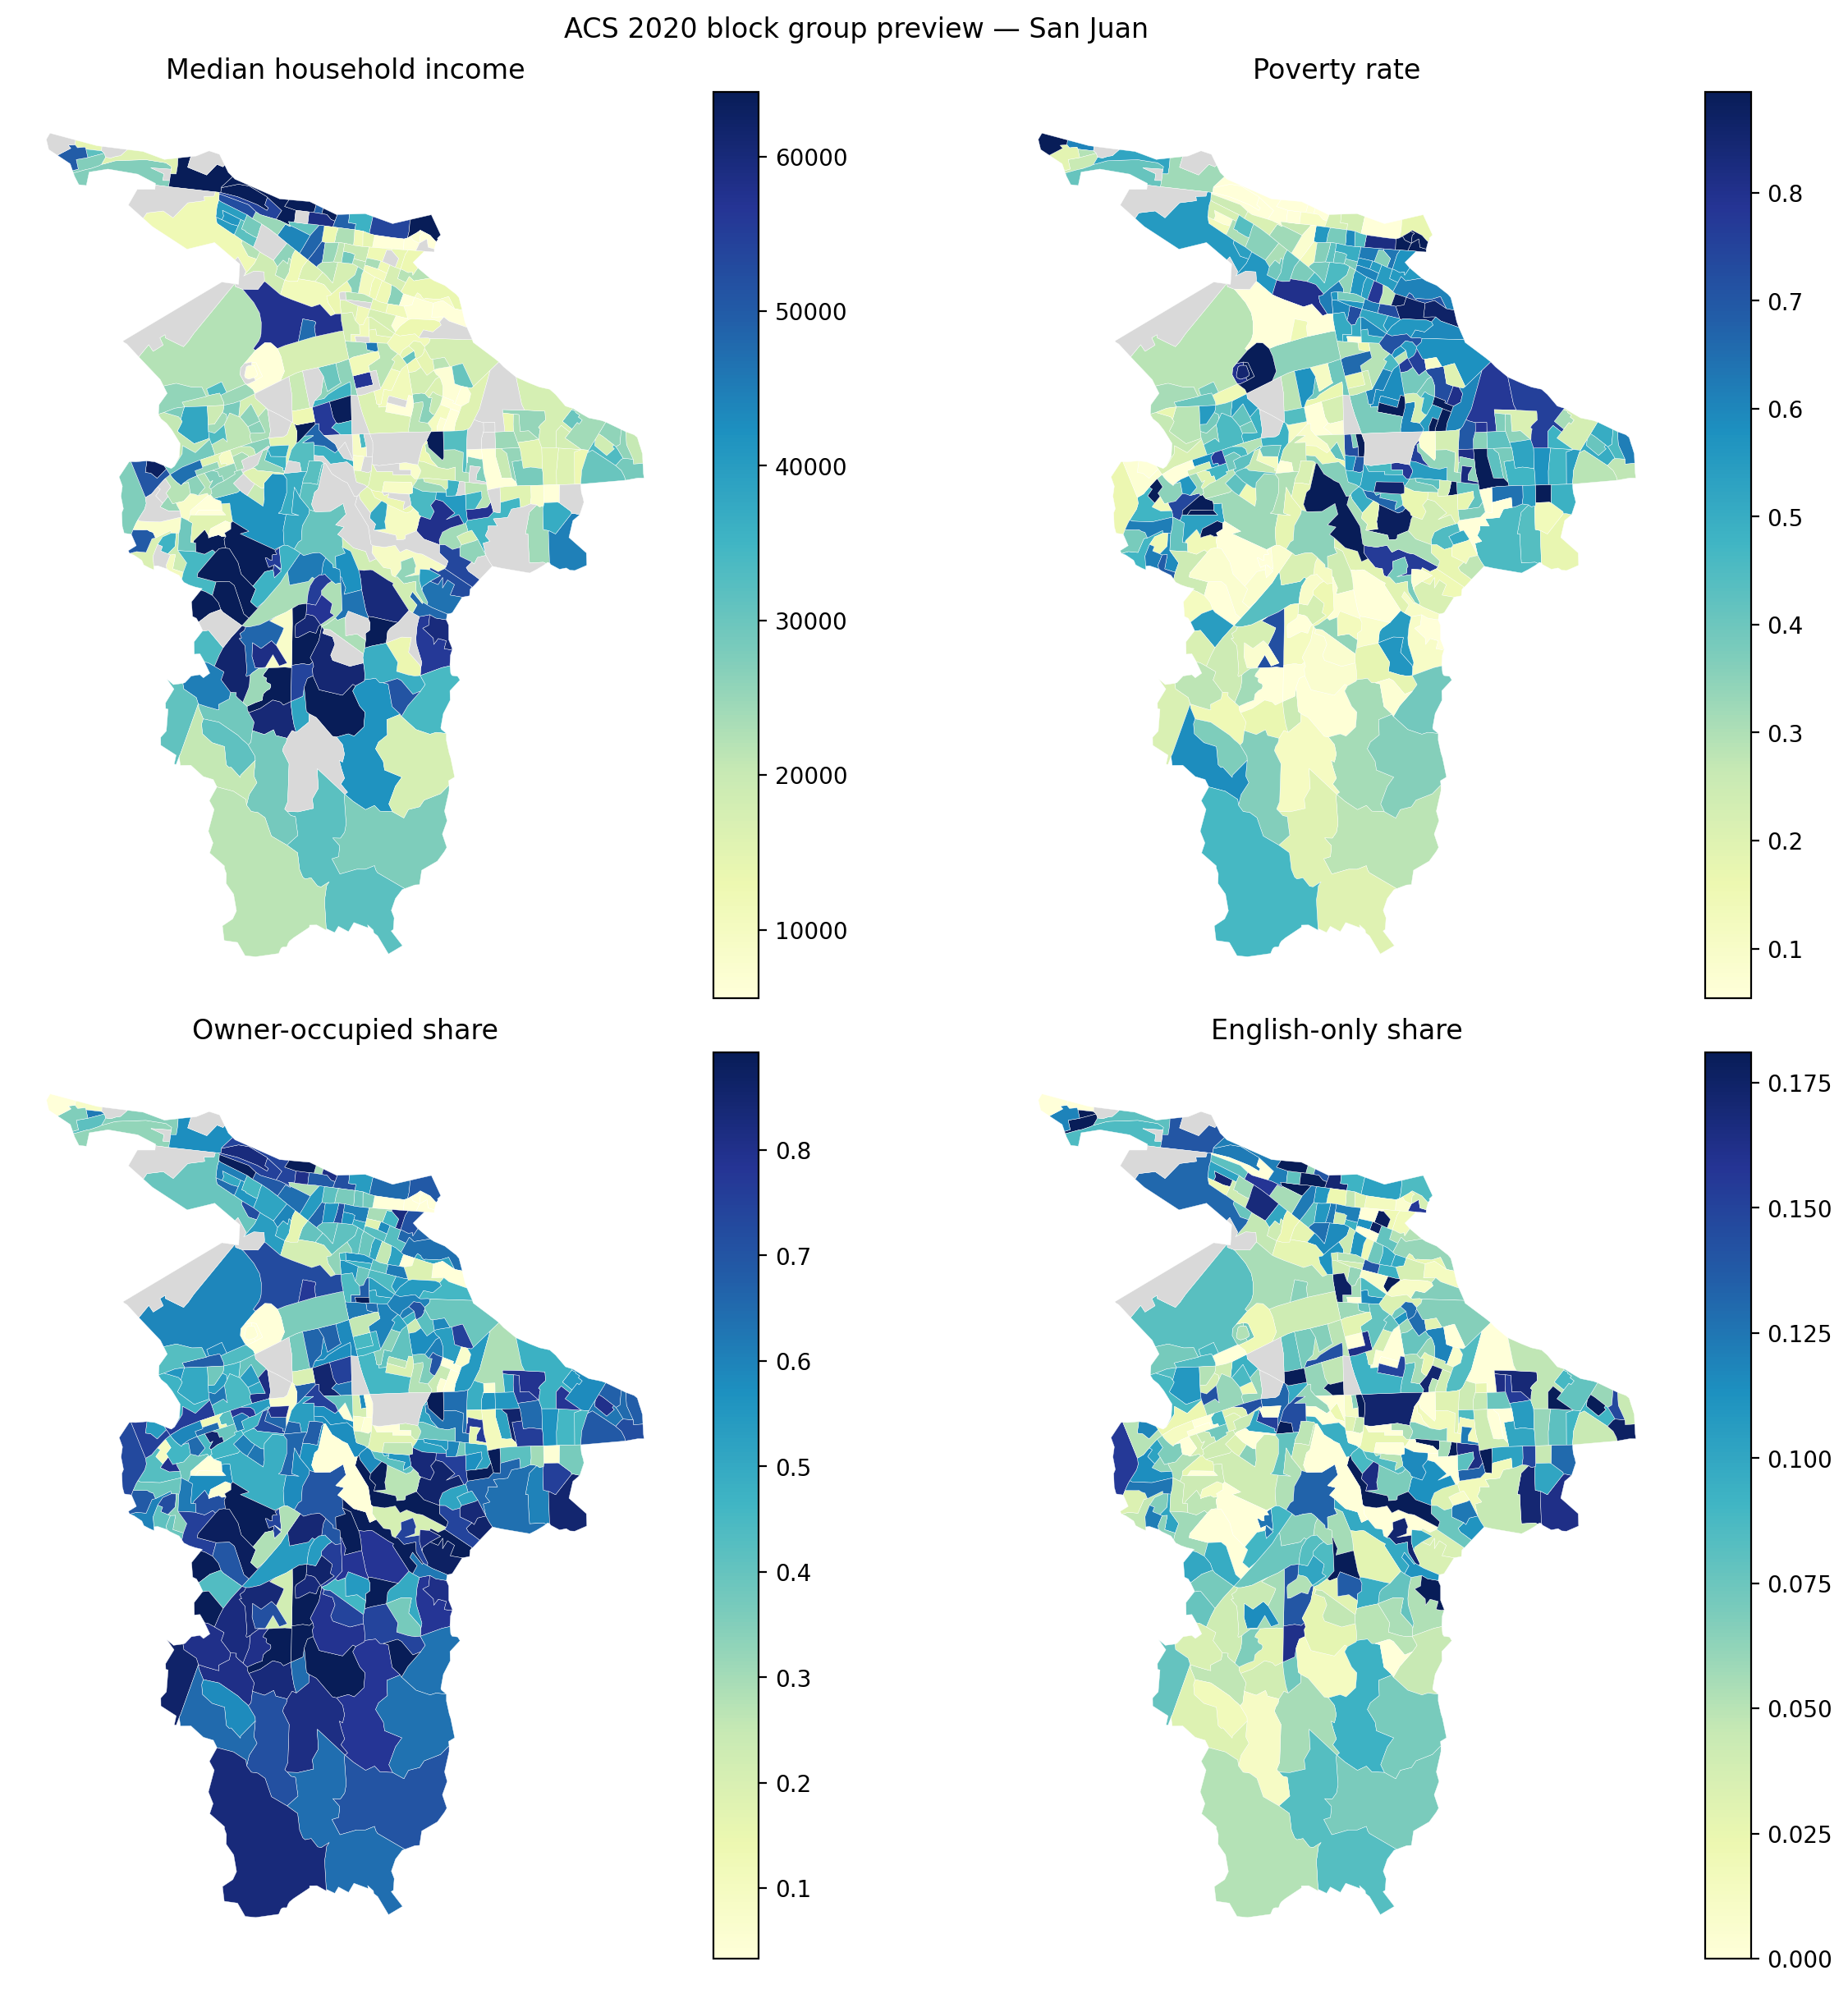

/home/asvnpr/Documents/repos/PLAN6068_PV_Project/outputs/figures/acs_2020_block_group_isabela_preview.png


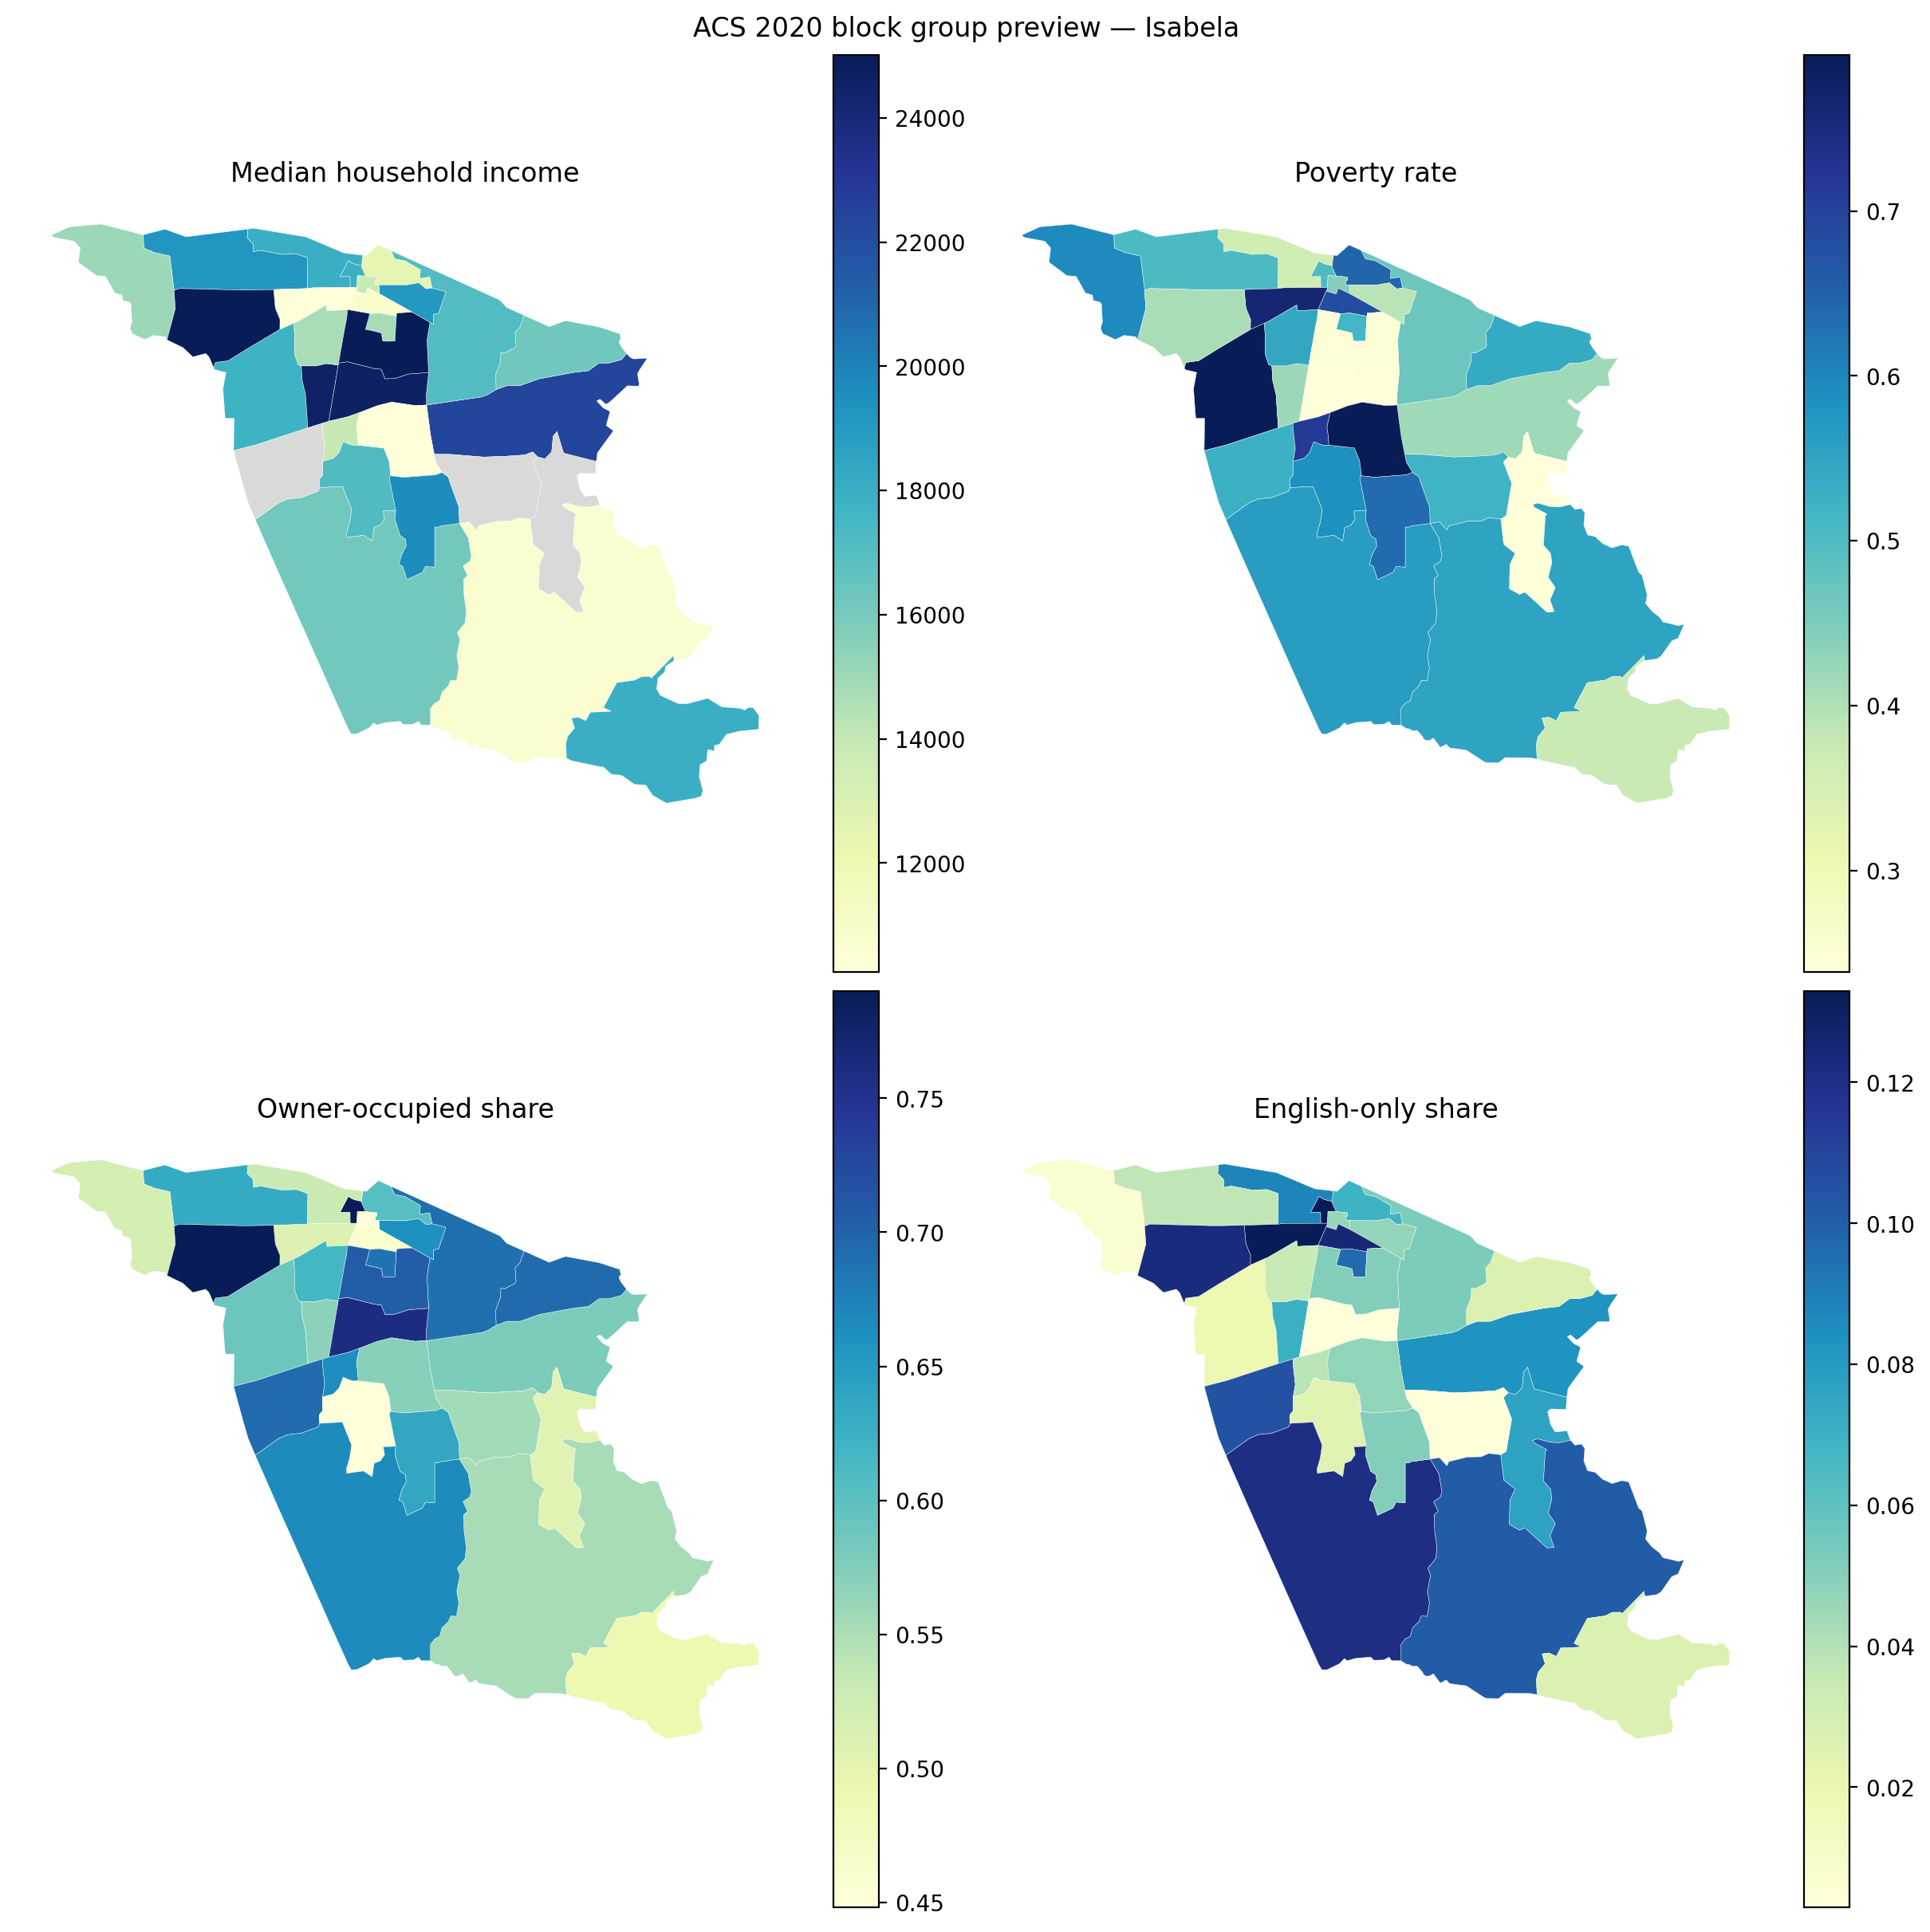

In [8]:
# display rendered ACS choropleth previews for the case-study municipalities
for preview_path in preview_paths:
    print(preview_path)
    display(Image(filename=str(preview_path)))